# SENTINEL · Notebook 4 · `optimizer/`

**What this notebook builds:** the **Allocation Model** from slide 4, the brain of SENTINEL:

$$\max \sum x_{pha}\, S_c(t + \tau_{pha}) \;-\; \lambda\cdot\text{overload} \;-\; \mu\cdot\text{unserved Red}$$

> *S = survival probability decaying with time to care · subject to bed/ICU/OT capacity minus reserve, ALS for Red, specialty fit, reachable route, blood-group stock, fund earmarks, zone fairness*
> *OR-Tools CP-SAT · warm start · greedy fallback if timeout*

Then it runs the whole 2-hour disaster three times and compares **SENTINEL** with the two static rules named in the problem statement: **nearest hospital** and **first-come-first-served (FCFS)**.

### How to use it
1. Tap **☰ → Runtime → Run all** and keep your screen on. The full comparison (Step 7) takes **1–4 minutes**.
2. If Colab shows a **"Restart session"** button after Step 1, tap it, then **Run all** again.
3. `NameError` = an earlier step didn't run → **Run all** again. Any other red error → screenshot to Claude.

## Step 1 · Install the tools and load everything
**OR-Tools** is Google's free optimisation library. Its **CP-SAT** solver is what decides the plan.

In [1]:
!pip install -q ortools "osmnx>=2.0,<3" folium
import json, os, sys, importlib, math
import pandas as pd
import matplotlib.pyplot as plt
import folium
import osmnx as ox
from google.colab import drive
drive.mount('/content/drive')

BASE = "/content/drive/MyDrive/SENTINEL"
DATA_DIR = f"{BASE}/data"
for folder in ["routing", "optimizer", "demand"]:
    os.makedirs(f"{BASE}/code/{folder}", exist_ok=True)
    if f"{BASE}/code/{folder}" not in sys.path:
        sys.path.insert(0, f"{BASE}/code/{folder}")

needed = [f"{DATA_DIR}/mumbai_roads.graphml", f"{DATA_DIR}/scenario.json", f"{DATA_DIR}/area.json",
          f"{BASE}/code/demand/demand_model.py"]
missing = [p.replace(BASE + "/", "") for p in needed if not os.path.exists(p)]
if missing:
    print("❌ Missing:", missing, "→ finish Notebooks 1, 2 and 3 first.")
else:
    G = ox.io.load_graphml(f"{DATA_DIR}/mumbai_roads.graphml")
    with open(f"{DATA_DIR}/scenario.json") as f:
        S = json.load(f)
    with open(f"{DATA_DIR}/area.json") as f:
        area = json.load(f)
    FLOOD_CENTER = tuple(area["flood_center"])
    import demand_model as dm
    importlib.reload(dm)
    print(f"✅ Step 1 done: {len(S['casualties'])} casualties, {len(S['hospitals'])} hospitals, "
          f"{len(S['ambulances'])} ambulances, demand model loaded")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 29.8/29.8 MB 29.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 104.7/104.7 kB 4.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 137.4/137.4 kB 3.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 323.4/323.4 kB 8.4 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
grpcio-status 1.71.2 requires protobuf<6.0dev,>=5.26.1, but you have protobuf 6.33.6 which is incompatible.
google-ai-generativelanguage 0.6.15 requires protobuf!=4.21.0,!=4.21.1,!=4.21.2,!=4.21.3,!=4.21.4,!=4.21.5,<6.0.0dev,>=3.20.2, but you have protobuf 6.33.6 which is incompatible.
Mounted at /content/drive
✅ Step 1 done: 160 casualties, 12 hospitals, 14 ambulances, demand model loaded


## Step 2 · The survival curve $S_c(t)$
The longer a patient waits for care, the lower their chance of survival. Each triage colour drops at a different speed:

$$S_c(t) = s_0 \cdot e^{-t/\tau}$$

| Colour | $s_0$ (survival with instant care) | $\tau$ (how slowly it drops) |
|---|---|---|
| Red | 0.90 | 90 min |
| Yellow | 0.97 | 400 min |
| Green | 0.995 | 4000 min |
| Grey | 0.10 | 60 min |

The *shape* follows the resource-constrained triage research in our deck (Sacco; ReSTART). The exact numbers are **assumed** for the demo.
A Yellow patient who deteriorates starts dropping at the Red speed.

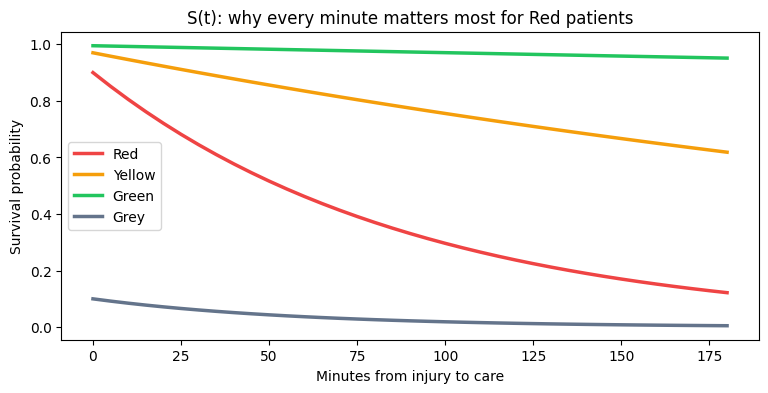

  care after  30 min → Red 64% · Yellow 90%
  care after  60 min → Red 46% · Yellow 83%
  care after 120 min → Red 24% · Yellow 72%
✅ Step 2 done


In [2]:
CURVES = {"RED": (0.90, 90), "YELLOW": (0.97, 400), "GREEN": (0.995, 4000), "GREY": (0.10, 60)}
COLOURS = {"RED": "#EF4444", "YELLOW": "#F59E0B", "GREEN": "#22C55E", "GREY": "#64748B"}
ts = list(range(0, 181, 5))
fig, ax = plt.subplots(figsize=(9, 4))
for c, (s0, tau) in CURVES.items():
    ax.plot(ts, [s0 * math.exp(-t / tau) for t in ts], color=COLOURS[c], linewidth=2.5, label=c.title())
ax.set_xlabel("Minutes from injury to care")
ax.set_ylabel("Survival probability")
ax.set_title("S(t): why every minute matters most for Red patients")
ax.legend()
plt.show()
for t in [30, 60, 120]:
    print(f"  care after {t:>3} min → Red {0.90 * math.exp(-t / 90):.0%} · Yellow {0.97 * math.exp(-t / 400):.0%}")
print("✅ Step 2 done")

## Step 3 · Save the Routing Model as a file
This packages Notebook 1's routing work (flooded roads slower, closed roads removed, travel-time matrix rebuilt) into
**Drive → SENTINEL → code → routing → routing_model.py**, so the optimiser and the website can use it.
When it finishes it says **"Writing…"**, not ✅. That's normal.

In [3]:
%%writefile /content/drive/MyDrive/SENTINEL/code/routing/routing_model.py
# SENTINEL routing/ · Routing Model
# Dijkstra / A* on the OpenStreetMap road graph; blocked edges removed,
# flooded edges time-penalised, travel-time matrix rebuilt on each closure.
import math
import networkx as nx


def straight_line_m(lat1, lon1, lat2, lon2):
    r = 6371000
    p1, p2 = math.radians(lat1), math.radians(lat2)
    dp, dl = p2 - p1, math.radians(lon2 - lon1)
    a = math.sin(dp / 2) ** 2 + math.cos(p1) * math.cos(p2) * math.sin(dl / 2) ** 2
    return 2 * r * math.asin(math.sqrt(a))


def close_road(graph, u, v):
    for a, b in [(u, v), (v, u)]:
        while graph.has_edge(a, b):
            graph.remove_edge(a, b)


def road_state_key(events, minute):
    # Identifies which version of the road network applies at this minute
    floods = [i for i, e in enumerate(events) if e["type"] == "flood" and e["t"] <= minute]
    closures = [i for i, e in enumerate(events) if e["type"] == "road_closed" and e["t"] <= minute]
    return (floods[-1] if floods else None, tuple(closures))


def live_graph(G, events, minute, flood_center):
    # The road network as it is at `minute`: flooded roads slower, closed roads removed
    Gl = G.copy()
    floods = [e for e in events if e["type"] == "flood" and e["t"] <= minute]
    if floods:
        f = floods[-1]
        for u, v, k, d in Gl.edges(keys=True, data=True):
            mid_lat = (Gl.nodes[u]["y"] + Gl.nodes[v]["y"]) / 2
            mid_lon = (Gl.nodes[u]["x"] + Gl.nodes[v]["x"]) / 2
            if straight_line_m(mid_lat, mid_lon, flood_center[0], flood_center[1]) <= f["radius_m"]:
                d["travel_time"] = d["travel_time"] * f["factor"]
    for e in events:
        if e["type"] == "road_closed" and e["t"] <= minute:
            close_road(Gl, e["u"], e["v"])
    return Gl


class TravelTimes:
    # Travel-time matrix for one version of the road network (Dijkstra, cached)
    def __init__(self, graph):
        self.G = graph
        self.R = graph.reverse(copy=False)
        self._from, self._to = {}, {}

    def from_node(self, n):
        if n not in self._from:
            self._from[n] = nx.single_source_dijkstra_path_length(self.G, n, weight="travel_time")
        return self._from[n]

    def to_node(self, n):
        if n not in self._to:
            self._to[n] = nx.single_source_dijkstra_path_length(self.R, n, weight="travel_time")
        return self._to[n]

    def minutes(self, a, b):
        # Minutes from junction a to junction b, or None if no road connects them
        s = self.to_node(b).get(a)
        return None if s is None else s / 60


def astar_route(graph, a, b):
    top_speed = max(d["speed_kph"] for _, _, d in graph.edges(data=True)) / 3.6

    def guess(u, v):
        return straight_line_m(graph.nodes[u]["y"], graph.nodes[u]["x"],
                               graph.nodes[v]["y"], graph.nodes[v]["x"]) / top_speed
    try:
        return nx.astar_path(graph, a, b, heuristic=guess, weight="travel_time")
    except (nx.NetworkXNoPath, nx.NodeNotFound):
        return None

Writing /content/drive/MyDrive/SENTINEL/code/routing/routing_model.py


## Step 4 · Save the Allocation Model as a file
This is the biggest piece of code in SENTINEL. You don't need to understand every line. Here is what each part does:

| Slide 4 says | In the code |
|---|---|
| $x_{pha}$: patient *p* → hospital *h* by ambulance *a* | `build_options` creates every allowed triple; CP-SAT picks 0 or 1 for each |
| $S_c(t+\tau_{pha})$ | `survival_at_care`: survival when the patient reaches care, including operating-theatre queue |
| − λ · overload | `overload_…` variables: patients above a hospital's normal beds (λ = 150) |
| − μ · unserved Red | `wait_…` variables for Red patients left waiting (μ = 300) |
| Bed / ICU / OT capacity **minus reserve** | bed and ICU limits; Yellow patients can't use beds held back for **unreported** Red patients (from buffer U) |
| ALS for Red | Red patients only get ALS ambulances |
| Specialty fit | burns, dialysis, trauma, paediatric must match the hospital |
| Reachable route | no option if the road network can't reach the hospital |
| Blood-group stock | units needed ≤ compatible stock at that hospital |
| Fund earmarks | spending per category ≤ earmarked money (+ the "any" pool) |
| Zone fairness | each zone's share of patients served stays within 30% of the average |
| Warm start | the greedy plan is given to CP-SAT as a starting hint |
| Greedy fallback | if CP-SAT runs out of time, the greedy plan is used instantly |

When it finishes it says **"Writing…"**.

In [4]:
%%writefile /content/drive/MyDrive/SENTINEL/code/optimizer/optimizer_model.py
# SENTINEL optimizer/ · Allocation Model (MIP / CP-SAT)
#   max Σ x_pha · S_c(t + τ_pha) − λ · overload − μ · unserved Red
#   subject to: bed/ICU/OT capacity minus reserve, ALS for Red, specialty fit,
#   reachable route, blood-group stock, fund earmarks, zone fairness
import math
import time
from ortools.sat.python import cp_model
from routing_model import TravelTimes, live_graph, road_state_key

# ---------- Survival curves S_c(t) = s0 · e^(−t/τ)  (shape after Sacco / ReSTART; parameters assumed) ----------
SURVIVAL = {"RED": (0.90, 90), "YELLOW": (0.97, 400), "GREEN": (0.995, 4000), "GREY": (0.10, 60)}

# ---------- Model settings ----------
LOAD_MIN, HANDOVER_MIN = 5, 10           # minutes to load a patient / hand over at hospital
DELAY_MIN = {"no_specialty": 60, "over_surge": 60, "icu_full": 60, "no_blood": 30}   # outcome model (assumed)
LAMBDA_OVERLOAD = 150                    # λ: penalty per patient above a hospital's normal beds
MU_UNSERVED_RED = 300                    # μ: penalty per Red patient left waiting
FAIRNESS_EPS, FAIRNESS_WEIGHT = 0.3, 3   # zone fairness: served share within 30% of the average
KM_PER_MIN = 0.4                         # ~24 km/h average, for transport cost
TIME_LIMIT_S = 3.0                       # CP-SAT time limit per re-plan
MAX_AMB, MAX_HOSP = 4, 6                 # candidate ambulances / hospitals kept per patient

COMPATIBLE = {"O-": ["O-"], "O+": ["O+", "O-"], "A-": ["A-", "O-"], "A+": ["A+", "A-", "O+", "O-"],
              "B-": ["B-", "O-"], "B+": ["B+", "B-", "O+", "O-"], "AB-": ["AB-", "A-", "B-", "O-"],
              "AB+": ["AB+", "AB-", "A+", "A-", "B+", "B-", "O+", "O-"]}


def survival(colour, minutes):
    s0, tau = SURVIVAL[colour]
    return s0 * math.exp(-max(minutes, 0) / tau)


def survival_at_care(p, care_minute):
    # Survival probability if definitive care starts at care_minute (Yellow decays like Red once it deteriorates)
    inj, d = p["injured_at"], p.get("deteriorate_at")
    if p["triage"] == "YELLOW" and d is not None and care_minute > d:
        return survival("YELLOW", d - inj) * math.exp(-(care_minute - d) / SURVIVAL["RED"][1])
    return survival(p["triage"], care_minute - inj)


def colour_now(p, minute):
    d = p.get("deteriorate_at")
    if p["triage"] == "YELLOW" and d is not None and minute >= d:
        return "RED"
    return p["triage"]


def needs_icu(p):
    # Half of Red patients need ICU (w_ICU = 0.5 in the demand model)
    return p["triage"] == "RED" and int(p["id"][1:]) % 2 == 0


# ---------- The world: hospitals, ambulances, funds as they change ----------
class World:
    def __init__(self, S):
        self.S = S
        self.hosp = {h["id"]: {"id": h["id"], "name": h["name"], "node": h["node"], "lat": h["lat"], "lon": h["lon"],
                               "beds": h["beds"], "icu": h["icu"], "surge": h["surge_pct"], "ot": h["ot_per_hr"],
                               "spec": set(h["specialties"]), "blood": dict(h["blood"]),
                               "beds_used": 0, "icu_used": 0, "red_arrivals": []} for h in S["hospitals"]}
        self.amb = {a["id"]: {**a, "free_at": 0, "at": a["node"]} for a in S["ambulances"]}
        self.funds = {"treatment": 0, "blood": 0, "transport": 0, "any": 0}
        for d in S["donations"]:
            self.funds[d["earmark"]] += d["amount"]
        self.spent = {"treatment": 0, "blood": 0, "transport": 0, "any": 0}
        self.unfunded = 0
        self.applied, self.dispatched = set(), {}

    def apply_events(self, minute):
        for i, e in enumerate(self.S["events"]):
            if i in self.applied or e["t"] > minute:
                continue
            if e["type"] == "hospital_down":
                h = self.hosp[e["hospital"]]
                h["beds"], h["icu"] = h["beds"] // 2, 0
            elif e["type"] == "blood_shortage":
                self.hosp[e["hospital"]]["blood"][e["group"]] = 0
            self.applied.add(i)

    def bed_cap(self, h):
        return int(h["beds"] * (1 + h["surge"] / 100))

    def free_beds(self, h):
        return max(0, self.bed_cap(h) - h["beds_used"])

    def free_icu(self, h):
        return max(0, h["icu"] - h["icu_used"])

    def blood_for(self, h, group):
        return sum(h["blood"].get(g, 0) for g in COMPATIBLE[group])

    def take_blood(self, h, group, units):
        for g in COMPATIBLE[group]:
            take = min(units, h["blood"].get(g, 0))
            h["blood"][g] -= take
            units -= take

    def ot_queue(self, h, minute):
        # Expected wait for an operating theatre: Red arrivals in the last hour ÷ theatre throughput
        if h["ot"] <= 0:
            return 120
        recent = [t for t in h["red_arrivals"] if minute - 60 <= t <= minute]
        return min(120.0, 30.0 * len(recent) / h["ot"])

    def funds_left(self):
        left = {k: self.funds[k] - self.spent[k] for k in ["treatment", "blood", "transport"]}
        left["any"] = self.funds["any"] - self.spent["any"]
        return left

    def spend(self, category, amount):
        own = max(0, self.funds[category] - self.spent[category])
        from_own = min(own, amount)
        self.spent[category] += from_own
        rest = amount - from_own
        from_any = min(max(0, self.funds["any"] - self.spent["any"]), rest)
        self.spent["any"] += from_any
        self.unfunded += rest - from_any


def waiting_patients(world, minute):
    # Known Red/Yellow patients not yet picked up (Green walk or go by bus; Grey get care on site)
    return [p for p in world.S["casualties"]
            if p["injured_at"] <= minute and p["reported_at"] <= minute
            and p["id"] not in world.dispatched and colour_now(p, minute) in ("RED", "YELLOW")]


def make_option(world, p, h, a, minute, t_ap, t_ph):
    col = colour_now(p, minute)
    arrival = minute + t_ap + LOAD_MIN + t_ph
    q = world.ot_queue(h, arrival) if col == "RED" else 0
    s = survival_at_care(p, arrival + q)
    km = (t_ap + t_ph) * KM_PER_MIN
    costs = world.S["unit_costs"]
    return {"p": p, "h": h, "a": a, "colour": col, "t_ap": t_ap, "t_ph": t_ph, "arrival": arrival, "queue": q,
            "survival": s, "score": int(round(1000 * s)),
            "cost_treatment": int(costs["treatment"][col]),
            "cost_blood": int(costs["blood_per_unit"] * p["blood_units"]),
            "cost_transport": int(round(costs["transport_per_km"][a["type"]] * km))}


def build_options(world, tt, waiting, idle, minute):
    # Feasible (patient, hospital, ambulance) triples: ALS for Red, specialty fit, OT/ICU, reachable route
    opts = []
    for p in waiting:
        col = colour_now(p, minute)
        ambs = []
        for a in idle:
            if col == "RED" and a["type"] != "ALS":
                continue
            t = tt.minutes(a["at"], p["node"])
            if t is not None:
                ambs.append((t, a))
        ambs = sorted(ambs, key=lambda x: x[0])[:MAX_AMB]
        hosps = []
        for h in world.hosp.values():
            if p["specialty"] not in h["spec"]:
                continue
            if col == "RED" and h["ot"] <= 0:
                continue
            if needs_icu(p) and h["icu"] <= 0:
                continue
            t = tt.minutes(p["node"], h["node"])
            if t is not None:
                hosps.append((t, h))
        hosps = sorted(hosps, key=lambda x: x[0])[:MAX_HOSP]
        for t_ap, a in ambs:
            for t_ph, h in hosps:
                opts.append(make_option(world, p, h, a, minute, t_ap, t_ph))
    return opts


def reserve_by_hospital(world, dm, minute, zones, starts):
    # "Capacity minus reserve": hold back beds for people not yet reported (from the demand model's buffer U)
    r = dm.unreported_reserve(world.S["casualties"], minute, zones, starts, frozenset(world.dispatched))
    free = {hid: world.free_beds(h) for hid, h in world.hosp.items()}
    total = sum(free.values())
    return {hid: (int(round(r["beds"] * f / total)) if total else 0) for hid, f in free.items()}, r


def _fits(world, o, taken, reserve, spend_tmp):
    p, h, hid = o["p"], o["h"], o["h"]["id"]
    if o["a"]["id"] in taken["amb"]:
        return False
    beds = taken["beds"].get(hid, 0) + 1
    if beds > world.free_beds(h):
        return False
    if o["colour"] != "RED" and beds > world.free_beds(h) - reserve.get(hid, 0):
        return False
    if needs_icu(p) and taken["icu"].get(hid, 0) + 1 > world.free_icu(h):
        return False
    u = p["blood_units"]
    if u and (taken["blood"].get((hid, p["blood_group"]), 0) + u > world.blood_for(h, p["blood_group"])
              or taken["blood_total"].get(hid, 0) + u > sum(h["blood"].values())):
        return False
    left = world.funds_left()
    extra = 0
    for cat, key in [("treatment", "cost_treatment"), ("blood", "cost_blood"), ("transport", "cost_transport")]:
        extra += max(0, spend_tmp[cat] + o[key] - max(left[cat], 0))
    return extra <= max(left["any"], 0)


def greedy_plan(world, opts, waiting, minute, reserve):
    # Fallback: Red first, then by report time; each takes its best feasible option
    by_p = {}
    for i, o in enumerate(opts):
        by_p.setdefault(o["p"]["id"], []).append(i)
    order = sorted(waiting, key=lambda p: (colour_now(p, minute) != "RED", p["reported_at"], p["id"]))
    taken = {"amb": set(), "beds": {}, "icu": {}, "blood": {}, "blood_total": {}}
    spend_tmp = {"treatment": 0, "blood": 0, "transport": 0}
    chosen = []
    for p in order:
        best = None
        for i in by_p.get(p["id"], []):
            o = opts[i]
            if not _fits(world, o, taken, reserve, spend_tmp):
                continue
            h = o["h"]
            over = 1 if h["beds_used"] + taken["beds"].get(h["id"], 0) + 1 > h["beds"] else 0
            val = o["score"] - LAMBDA_OVERLOAD * over
            if best is None or val > best[0]:
                best = (val, i)
        if best:
            o, hid = opts[best[1]], opts[best[1]]["h"]["id"]
            taken["amb"].add(o["a"]["id"])
            taken["beds"][hid] = taken["beds"].get(hid, 0) + 1
            if needs_icu(p):
                taken["icu"][hid] = taken["icu"].get(hid, 0) + 1
            if p["blood_units"]:
                k = (hid, p["blood_group"])
                taken["blood"][k] = taken["blood"].get(k, 0) + p["blood_units"]
                taken["blood_total"][hid] = taken["blood_total"].get(hid, 0) + p["blood_units"]
            for cat, key in [("treatment", "cost_treatment"), ("blood", "cost_blood"), ("transport", "cost_transport")]:
                spend_tmp[cat] += o[key]
            chosen.append(best[1])
    return chosen


def cpsat_plan(world, opts, waiting, minute, reserve, hint=None, time_limit=TIME_LIMIT_S):
    # The CP-SAT model: every waiting patient, hospital and ambulance decided together
    if not opts:
        return [], "NO OPTIONS", 0.0
    model = cp_model.CpModel()
    x = [model.new_bool_var(f"x{i}") for i in range(len(opts))]
    pids = [p["id"] for p in waiting]
    y = {pid: model.new_bool_var(f"wait_{pid}") for pid in pids}
    by_p, by_a, by_h = {}, {}, {}
    for i, o in enumerate(opts):
        by_p.setdefault(o["p"]["id"], []).append(i)
        by_a.setdefault(o["a"]["id"], []).append(i)
        by_h.setdefault(o["h"]["id"], []).append(i)

    for pid in pids:                                        # each patient: one trip or waits
        model.add(sum(x[i] for i in by_p.get(pid, [])) + y[pid] == 1)
    for idx in by_a.values():                               # each ambulance: one trip
        model.add(sum(x[i] for i in idx) <= 1)
    overload = []
    for hid, idx in by_h.items():
        h = world.hosp[hid]
        model.add(sum(x[i] for i in idx) <= world.free_beds(h))                     # bed capacity (incl. surge)
        yellow = [i for i in idx if opts[i]["colour"] != "RED"]
        if yellow:                                                                   # minus reserve for unreported
            model.add(sum(x[i] for i in yellow) <= max(0, world.free_beds(h) - reserve.get(hid, 0)))
        icu = [i for i in idx if needs_icu(opts[i]["p"])]
        if icu:                                                                      # ICU capacity
            model.add(sum(x[i] for i in icu) <= world.free_icu(h))
        groups = {}
        for i in idx:
            if opts[i]["p"]["blood_units"]:
                groups.setdefault(opts[i]["p"]["blood_group"], []).append(i)
        for g, gi in groups.items():                                                 # blood-group stock
            model.add(sum(x[i] * opts[i]["p"]["blood_units"] for i in gi) <= world.blood_for(h, g))
        if groups:
            allb = [i for gi in groups.values() for i in gi]
            model.add(sum(x[i] * opts[i]["p"]["blood_units"] for i in allb) <= sum(h["blood"].values()))
        o_h = model.new_int_var(0, 10000, f"overload_{hid}")                          # λ · overload
        model.add(o_h >= h["beds_used"] + sum(x[i] for i in idx) - h["beds"])
        overload.append(o_h)

    left = world.funds_left()                                                       # fund earmarks
    any_left = max(left["any"], 0)
    pools = []
    for cat, key in [("treatment", "cost_treatment"), ("blood", "cost_blood"), ("transport", "cost_transport")]:
        pool = model.new_int_var(0, any_left, f"any_{cat}")
        model.add(sum(x[i] * opts[i][key] for i in range(len(opts))) <= max(left[cat], 0) + pool)
        pools.append(pool)
    model.add(sum(pools) <= any_left)

    shortfall = []                                                                  # zone fairness
    zones = {}
    for p in waiting:
        zones.setdefault(p["zone"], []).append(p["id"])
    n = len(pids)
    if len(zones) > 1:
        served_total = n - sum(y.values())
        for z, members in zones.items():
            nz = len(members)
            served_z = nz - sum(y[m] for m in members)
            s = model.new_int_var(0, n * nz + 1, f"short_{z}")
            model.add(n * served_z - nz * served_total + math.ceil(FAIRNESS_EPS * n * nz) + s >= 0)
            shortfall.append(s)

    reds = [y[p["id"]] for p in waiting if colour_now(p, minute) == "RED"]
    model.maximize(sum(opts[i]["score"] * x[i] for i in range(len(opts)))
                   - LAMBDA_OVERLOAD * sum(overload) - MU_UNSERVED_RED * sum(reds)
                   - FAIRNESS_WEIGHT * sum(shortfall))

    if hint is not None:                                                            # warm start
        hs = set(hint)
        for i in range(len(opts)):
            model.add_hint(x[i], 1 if i in hs else 0)
        served = {opts[i]["p"]["id"] for i in hs}
        for pid in pids:
            model.add_hint(y[pid], 0 if pid in served else 1)

    solver = cp_model.CpSolver()
    solver.parameters.max_time_in_seconds = time_limit
    solver.parameters.num_workers = 4
    t0 = time.time()
    status = solver.solve(model)
    ms = (time.time() - t0) * 1000
    if status in (cp_model.OPTIMAL, cp_model.FEASIBLE):
        return [i for i in range(len(opts)) if solver.value(x[i])], solver.status_name(status), ms
    return None, solver.status_name(status), ms


def nearest_plan(world, tt, waiting, idle, minute):
    # Baseline 1: Red first; each goes to the NEAREST hospital, ignoring capacity and specialty
    order = sorted(waiting, key=lambda p: (colour_now(p, minute) != "RED", p["reported_at"], p["id"]))
    free, out = list(idle), []
    for p in order:
        col = colour_now(p, minute)
        hs = [(tt.minutes(p["node"], h["node"]), h) for h in world.hosp.values()]
        hs = [x for x in hs if x[0] is not None]
        ams = [(tt.minutes(a["at"], p["node"]), a) for a in free if col != "RED" or a["type"] == "ALS"]
        ams = [x for x in ams if x[0] is not None]
        if not hs or not ams:
            continue
        t_ph, h = min(hs, key=lambda x: x[0])
        t_ap, a = min(ams, key=lambda x: x[0])
        out.append(make_option(world, p, h, a, minute, t_ap, t_ph))
        free.remove(a)
    return out


def fcfs_plan(world, tt, waiting, idle, minute):
    # Baseline 2: first-come-first-served by report time; nearest hospital that still has a normal bed
    order = sorted(waiting, key=lambda p: (p["reported_at"], p["id"]))
    free, out, planned = list(idle), [], {}
    for p in order:
        col = colour_now(p, minute)
        hs = [(tt.minutes(p["node"], h["node"]), h) for h in world.hosp.values()]
        hs = sorted([x for x in hs if x[0] is not None], key=lambda x: x[0])
        ams = [(tt.minutes(a["at"], p["node"]), a) for a in free if col != "RED" or a["type"] == "ALS"]
        ams = [x for x in ams if x[0] is not None]
        if not hs or not ams:
            continue
        with_bed = [x for x in hs if x[1]["beds_used"] + planned.get(x[1]["id"], 0) < x[1]["beds"]]
        t_ph, h = (with_bed or hs)[0]
        t_ap, a = min(ams, key=lambda x: x[0])
        out.append(make_option(world, p, h, a, minute, t_ap, t_ph))
        planned[h["id"]] = planned.get(h["id"], 0) + 1
        free.remove(a)
    return out


def why_this_hospital(world, tt, o, reserve, minute):
    # "Why this hospital?" card: every hospital compared for this patient, with the reason it was or wasn't chosen
    p, a, rows = o["p"], o["a"], []
    for h in world.hosp.values():
        t_ph = tt.minutes(p["node"], h["node"])
        reason, surv = None, None
        if p["specialty"] not in h["spec"]:
            reason = f"no {p['specialty']} service"
        elif o["colour"] == "RED" and h["ot"] <= 0:
            reason = "no operating theatre"
        elif needs_icu(p) and h["icu"] <= 0:
            reason = "no ICU (or ICU lost)"
        elif t_ph is None:
            reason = "road cut off"
        else:
            arr = minute + o["t_ap"] + LOAD_MIN + t_ph
            q = world.ot_queue(h, arr) if o["colour"] == "RED" else 0
            surv = survival_at_care(p, arr + q)
            if h["id"] == o["h"]["id"]:
                reason = "CHOSEN"
            elif world.free_beds(h) <= 0:
                reason = "full"
            elif o["colour"] != "RED" and world.free_beds(h) - reserve.get(h["id"], 0) <= 0:
                reason = "beds held for unreported Red patients"
            elif needs_icu(p) and world.free_icu(h) <= 0:
                reason = "ICU full"
            elif p["blood_units"] and world.blood_for(h, p["blood_group"]) < p["blood_units"]:
                reason = f"not enough {p['blood_group']}-compatible blood"
            else:
                reason = "lower survival for the whole system when all patients are planned together"
        rows.append({"hospital": h["id"], "name": h["name"], "minutes": None if t_ph is None else round(t_ph, 1),
                     "survival": None if surv is None else round(surv, 3), "reason": reason})
    rows.sort(key=lambda r: (r["reason"] != "CHOSEN", -(r["survival"] or 0)))
    return rows


def dispatch(world, o, minute, policy, why=None):
    # Send the ambulance and score the outcome with the SAME rules for every policy
    p, h, a = o["p"], o["h"], o["a"]
    delay, problems = 0, []
    if p["specialty"] not in h["spec"]:
        delay += DELAY_MIN["no_specialty"]; problems.append("no specialty: transfer needed")
    if h["beds_used"] + 1 > world.bed_cap(h):
        delay += DELAY_MIN["over_surge"]; problems.append("hospital over surge capacity")
    if needs_icu(p):
        if h["icu_used"] + 1 > h["icu"]:
            delay += DELAY_MIN["icu_full"]; problems.append("ICU full")
        else:
            h["icu_used"] += 1
    if p["blood_units"]:
        if world.blood_for(h, p["blood_group"]) < p["blood_units"]:
            delay += DELAY_MIN["no_blood"]; problems.append("blood not in stock")
        else:
            world.take_blood(h, p["blood_group"], p["blood_units"])
    col = colour_now(p, o["arrival"])
    q = world.ot_queue(h, o["arrival"]) if col == "RED" else 0
    if col == "RED":
        h["red_arrivals"].append(o["arrival"])
    h["beds_used"] += 1
    care = o["arrival"] + q + delay
    s = survival_at_care(p, care)
    a["free_at"], a["at"] = o["arrival"] + HANDOVER_MIN, h["node"]
    world.spend("treatment", o["cost_treatment"])
    world.spend("blood", o["cost_blood"])
    world.spend("transport", o["cost_transport"])
    rec = {"policy": policy, "patient": p["id"], "zone": p["zone"], "triage": p["triage"], "colour_at_dispatch": o["colour"],
           "specialty": p["specialty"], "hospital": h["id"], "ambulance": a["id"], "ambulance_type": a["type"],
           "dispatch_min": minute, "arrival_min": round(o["arrival"], 1), "care_min": round(care, 1),
           "survival": round(s, 4), "problems": problems,
           "costs": {"treatment": o["cost_treatment"], "blood": o["cost_blood"], "transport": o["cost_transport"]}}
    if why is not None:
        rec["why"] = why
    world.dispatched[p["id"]] = rec
    return rec


def simulate(policy, S, G, flood_center, dm, epoch_min=5, time_limit=TIME_LIMIT_S):
    # Run the 2-hour disaster with one policy: "sentinel", "nearest" or "fcfs"
    world = World(S)
    zones, starts = S["zones"], dm.incident_starts(S["events"])
    cache, log = {}, []
    for minute in range(0, S["horizon_min"] + 1, epoch_min):
        world.apply_events(minute)
        key = road_state_key(S["events"], minute)
        if key not in cache:                     # travel-time matrix rebuilt on each closure / flood change
            cache[key] = TravelTimes(live_graph(G, S["events"], minute, flood_center))
        tt = cache[key]
        idle = [a for a in world.amb.values() if a["free_at"] <= minute]
        waiting = waiting_patients(world, minute)
        info = {"minute": minute, "waiting": len(waiting), "idle_ambulances": len(idle), "dispatched": 0}
        if waiting and idle:
            if policy == "sentinel":
                reserve, r = reserve_by_hospital(world, dm, minute, zones, starts)
                opts = build_options(world, tt, waiting, idle, minute)
                hint = greedy_plan(world, opts, waiting, minute, reserve)
                chosen, status, ms = cpsat_plan(world, opts, waiting, minute, reserve, hint, time_limit)
                if chosen is None:
                    chosen, status = hint, f"FALLBACK (greedy) after {status}"
                decisions = [opts[i] for i in chosen]
                info.update({"options": len(opts), "solver": status, "solve_ms": round(ms),
                             "reserve_beds": round(r["beds"], 1)})
                whys = [why_this_hospital(world, tt, o, reserve, minute) for o in decisions]
            else:
                decisions = (nearest_plan if policy == "nearest" else fcfs_plan)(world, tt, waiting, idle, minute)
                whys = [None] * len(decisions)
            for o, w in zip(decisions, whys):
                dispatch(world, o, minute, policy, w)
            info["dispatched"] = len(decisions)
        log.append(info)
    return world, log


def metrics(world, S):
    horizon = S["horizon_min"]
    pts = [p for p in S["casualties"] if p["triage"] in ("RED", "YELLOW")]
    surv, red_t, reached, transfers, overfull = 0.0, [], 0, 0, 0
    for p in pts:
        r = world.dispatched.get(p["id"])
        if r:
            surv += r["survival"]; reached += 1
            transfers += "no specialty: transfer needed" in r["problems"]
            overfull += "hospital over surge capacity" in r["problems"]
            care = r["care_min"]
        else:
            care = horizon + 60                   # not reached in 2 h: assume care one hour later
            surv += survival_at_care(p, care)
        if p["triage"] == "RED":
            red_t.append(care - p["injured_at"])
    load = max(h["beds_used"] / max(h["beds"], 1) * 100 for h in world.hosp.values())
    return {"Expected survivors (Red+Yellow)": round(surv, 1),
            "Red: avg minutes to care": round(sum(red_t) / len(red_t), 1),
            "Reached within 2 h": f"{reached}/{len(pts)}",
            "Needed transfer (wrong hospital)": transfers,
            "Arrived at over-full hospital": overfull,
            "Busiest hospital load %": round(load),
            "Spending outside earmarks (₹)": world.unfunded}


def log_override(override_log, minute, patient, from_h, to_h, actor, reason):
    # Human override: allowed, but always recorded (goes to the ledger in Notebook 5)
    entry = {"minute": minute, "patient": patient, "from": from_h, "to": to_h, "actor": actor, "reason": reason}
    override_log.append(entry)
    return entry

Writing /content/drive/MyDrive/SENTINEL/code/optimizer/optimizer_model.py


## Step 5 · One re-plan, up close (minute 20)
At minute 20 the second wave of reports arrives. We freeze time and let CP-SAT plan **every waiting patient, every hospital and every ambulance together**.

In [5]:
import routing_model as rm
import optimizer_model as om
importlib.reload(rm); importlib.reload(om)

MINUTE = 20
world = om.World(S)
world.apply_events(MINUTE)
tt = rm.TravelTimes(rm.live_graph(G, S["events"], MINUTE, FLOOD_CENTER))
idle = list(world.amb.values())
waiting = om.waiting_patients(world, MINUTE)
starts = dm.incident_starts(S["events"])
reserve, r = om.reserve_by_hospital(world, dm, MINUTE, S["zones"], starts)
opts = om.build_options(world, tt, waiting, idle, MINUTE)
hint = om.greedy_plan(world, opts, waiting, MINUTE, reserve)
chosen, status, ms = om.cpsat_plan(world, opts, waiting, MINUTE, reserve, hint)

print(f"Waiting Red/Yellow patients : {len(waiting)}")
print(f"Ambulances available        : {len(idle)}")
print(f"Allowed (patient, hospital, ambulance) options: {len(opts)}")
print(f"Beds held in reserve for unreported patients : {r['beds']:.0f}")
print(f"CP-SAT result: {status} in {ms:.0f} ms")
greedy_value = sum(opts[i]["survival"] for i in hint)
cpsat_value = sum(opts[i]["survival"] for i in chosen)
print(f"Expected survivors of this plan: greedy {greedy_value:.2f} → CP-SAT {cpsat_value:.2f}")

rows = [{"patient": opts[i]["p"]["id"], "colour": opts[i]["colour"], "zone": opts[i]["p"]["zone"],
         "→ hospital": opts[i]["h"]["id"], "ambulance": f"{opts[i]['a']['id']} {opts[i]['a']['type']}",
         "arrives (min)": round(opts[i]["arrival"]), "survival": f"{opts[i]['survival']:.0%}"} for i in chosen]
print("\nPLAN AT MINUTE 20")
print(pd.DataFrame(rows).sort_values("colour").to_string(index=False))
print("✅ Step 5 done")

Waiting Red/Yellow patients : 35
Ambulances available        : 14
Allowed (patient, hospital, ambulance) options: 740
Beds held in reserve for unreported patients : 29
CP-SAT result: FEASIBLE in 3005 ms
Expected survivors of this plan: greedy 9.00 → CP-SAT 9.55

PLAN AT MINUTE 20
patient colour zone → hospital ambulance  arrives (min) survival
   P012    RED   Z3         H3   A05 ALS             37      60%
   P022    RED   Z1        H10   A02 ALS             39      59%
   P096    RED   Z4         H9   A03 ALS             32      63%
   P120    RED   Z2        H10   A04 ALS             34      62%
   P026 YELLOW   Z4         H1   A08 BLS             33      89%
   P034 YELLOW   Z4         H4   A10 BLS             33      89%
   P035 YELLOW   Z1        H10   A09 BLS             37      88%
   P052 YELLOW   Z4         H4   A06 BLS             32      89%
   P069 YELLOW   Z5         H4   A01 ALS             34      89%
   P100 YELLOW   Z1        H10   A14 BLS             38      88%
   P

## Step 6 · Prove the fallback works
We give CP-SAT almost no time (0.001 s) on purpose. SENTINEL must still produce a plan, using the greedy fallback, so dispatch never waits.

In [6]:
chosen_fast, status_fast, ms_fast = om.cpsat_plan(world, opts, waiting, MINUTE, reserve, hint, time_limit=0.001)
if chosen_fast is None:
    print(f"CP-SAT status with 0.001 s: {status_fast} → greedy fallback used: {len(hint)} patients dispatched instantly")
else:
    print(f"CP-SAT still found a plan in {ms_fast:.0f} ms ({status_fast}); the fallback stays ready for bigger disasters")
print("✅ Step 6 done")

CP-SAT status with 0.001 s: UNKNOWN → greedy fallback used: 12 patients dispatched instantly
✅ Step 6 done


## Step 7 · The big test: SENTINEL vs nearest hospital vs FCFS
The same 2-hour disaster is run **three times**. Every 5 minutes (which includes every event) each policy decides who to send where.
All three are scored with **the same rules**: a patient at the wrong hospital needs a transfer (+60 min), a hospital over its surge capacity delays care (+60 min), and so on.

⏳ This takes 1–4 minutes. Keep your screen on.

In [7]:
import time
results, worlds, logs = {}, {}, {}
for policy, label in [("sentinel", "SENTINEL"), ("nearest", "Nearest hospital"), ("fcfs", "FCFS")]:
    t0 = time.time()
    worlds[policy], logs[policy] = om.simulate(policy, S, G, FLOOD_CENTER, dm)
    results[label] = om.metrics(worlds[policy], S)
    print(f"  {label:<17} finished in {time.time() - t0:.0f} s")

table = pd.DataFrame(results)
print("\nRESULTS (same disaster, same scoring rules)")
print(table.to_string())
s, n = results["SENTINEL"]["Expected survivors (Red+Yellow)"], results["Nearest hospital"]["Expected survivors (Red+Yellow)"]
print(f"\n→ SENTINEL: {s - n:+.1f} expected survivors vs nearest hospital ({100 * (s - n) / n:+.0f}%)")
print("✅ Step 7 done")

  SENTINEL          finished in 10 s
  Nearest hospital  finished in 6 s
  FCFS              finished in 2 s

RESULTS (same disaster, same scoring rules)
                                 SENTINEL Nearest hospital   FCFS
Expected survivors (Red+Yellow)      46.4             37.1   39.1
Red: avg minutes to care            107.3            155.9  137.1
Reached within 2 h                  55/72            58/72  55/72
Needed transfer (wrong hospital)        0               15     10
Arrived at over-full hospital           0                6      0
Busiest hospital load %                93              200    100
Spending outside earmarks (₹)           0                0      0

→ SENTINEL: +9.3 expected survivors vs nearest hospital (+25%)
✅ Step 7 done


## Step 8 · The comparison as a chart
These are the numbers for slide 7 and your demo video: **your own measured results**, not borrowed ones.

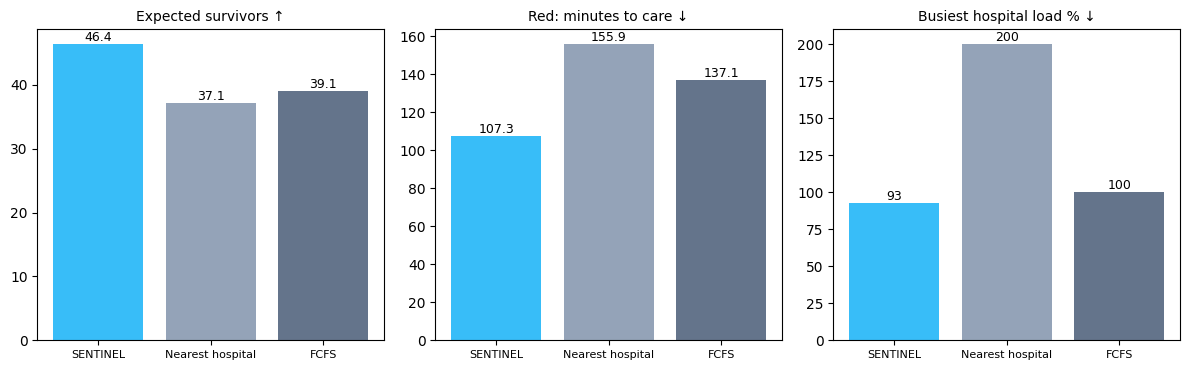

✅ Step 8 done


In [8]:
labels = list(results)
colors = ["#38BDF8", "#94A3B8", "#64748B"]
panels = [("Expected survivors (Red+Yellow)", "Expected survivors ↑"),
          ("Red: avg minutes to care", "Red: minutes to care ↓"),
          ("Busiest hospital load %", "Busiest hospital load % ↓")]
fig, axes = plt.subplots(1, 3, figsize=(12, 3.8))
for ax, (key, title) in zip(axes, panels):
    vals = [results[l][key] for l in labels]
    ax.bar(labels, vals, color=colors)
    ax.set_title(title, fontsize=10)
    ax.tick_params(axis="x", labelsize=8)
    for i, v in enumerate(vals):
        ax.text(i, v, f"{v}", ha="center", va="bottom", fontsize=9)
plt.tight_layout()
plt.show()
print("✅ Step 8 done")

## Step 9 · Event-driven re-planning log
Every row is one re-plan by SENTINEL. Look at the minutes with events (road closed at 35, hospital failure at 50, collapse at 75): the plan is rebuilt for **all** patients each time.

In [9]:
event_text = {e["t"]: e["text"][:38] for e in S["events"]}
rows = []
for l in logs["sentinel"]:
    if l["dispatched"] or l["minute"] in event_text:
        rows.append({"min": l["minute"], "waiting": l["waiting"], "amb free": l["idle_ambulances"],
                     "sent": l["dispatched"], "solver": l.get("solver", "-")[:8],
                     "ms": l.get("solve_ms", "-"), "event": event_text.get(l["minute"], "")})
print(pd.DataFrame(rows).to_string(index=False))
fallbacks = sum("FALLBACK" in l.get("solver", "") for l in logs["sentinel"])
print(f"\nRe-plans: {sum(1 for l in logs['sentinel'] if 'solver' in l)} · greedy fallbacks needed: {fallbacks}")
print("✅ Step 9 done")

 min  waiting  amb free  sent  solver  ms                                  event
   0       18        14    10 OPTIMAL 404 Flood begins: roads within 700 m of th
   5        8         4     4 OPTIMAL  11                                       
  25       21         3     3 OPTIMAL 137                                       
  30       18         7     6 OPTIMAL 795                                       
  35       12         2     2 OPTIMAL   6 Critical road closed (used by 24 faste
  40       10         2     2 OPTIMAL  14                                       
  45       20         2     2 OPTIMAL 104                                       
  50       18         2     2 OPTIMAL  30 H1 power failure: ICU lost, beds halve
  55       16         2     2 OPTIMAL   7                                       
  60       14         2     2 OPTIMAL 284 Flood worsens: 900 m radius, roads 5× 
  65       12         2     2 OPTIMAL  90                                       
  75       21         4     

## Step 10 · "Why this hospital?" cards
For every decision, SENTINEL records **every hospital it considered** and why it was or wasn't chosen: travel time, survival, beds, ICU, blood, specialty or reserve.

In [10]:
recs = list(worlds["sentinel"].dispatched.values())
examples = []
red_after_failure = [r for r in recs if r["colour_at_dispatch"] == "RED" and r["dispatch_min"] >= 50]
held = [r for r in recs if any("held for unreported" in w["reason"] for w in r.get("why", []))]
for group in [red_after_failure, held, recs]:
    if group and group[0] not in examples:
        examples.append(group[0])
for r in examples[:2]:
    print(f"PATIENT {r['patient']} · {r['colour_at_dispatch']} · {r['specialty']} · zone {r['zone']} · minute {r['dispatch_min']}")
    print(f"  Sent to {r['hospital']} by {r['ambulance']} ({r['ambulance_type']}), care at minute {r['care_min']}, survival {r['survival']:.0%}")
    for w in r["why"][:5]:
        surv = f"{w['survival']:.0%}" if w["survival"] is not None else "  - "
        mins = f"{w['minutes']} min" if w["minutes"] is not None else "   -  "
        print(f"   {w['hospital']:<4} {mins:>9}  survival {surv:>4}  {w['reason']}")
    print()
print("✅ Step 10 done")

PATIENT P111 · RED · trauma · zone Z4 · minute 60
  Sent to H1 by A02 (ALS), care at minute 74.6, survival 39%
   H1     3.3 min  survival  39%  CHOSEN
   H9     3.8 min  survival  39%  lower survival for the whole system when all patients are planned together
   H2     5.1 min  survival  38%  lower survival for the whole system when all patients are planned together
   H10   12.4 min  survival  36%  lower survival for the whole system when all patients are planned together
   H8    14.9 min  survival  34%  lower survival for the whole system when all patients are planned together

PATIENT P012 · RED · general · zone Z3 · minute 0
  Sent to H3 by A05 (ALS), care at minute 16.9, survival 75%
   H3     5.1 min  survival  75%  CHOSEN
   H1     5.4 min  survival  74%  lower survival for the whole system when all patients are planned together
   H4     5.4 min  survival  74%  lower survival for the whole system when all patients are planned together
   H9     6.6 min  survival  73%  lower s

## Step 11 · Human override (allowed, but always logged)
A commander can change any decision. SENTINEL allows it but records **who, when, what and why**. Notebook 5 writes this log into the tamper-evident ledger.

In [11]:
override_log = []
r = recs[0]
other = next(h["id"] for h in S["hospitals"] if h["id"] != r["hospital"])
entry = om.log_override(override_log, minute=r["dispatch_min"], patient=r["patient"], from_h=r["hospital"],
                        to_h=other, actor="DDMA commander (demo)", reason="Family requested hospital near home")
print("Override recorded:", entry)
print("✅ Step 11 done")

Override recorded: {'minute': 0, 'patient': 'P012', 'from': 'H3', 'to': 'H1', 'actor': 'DDMA commander (demo)', 'reason': 'Family requested hospital near home'}
✅ Step 11 done


## Step 12 · See both plans on a map
Use the **layer button** (top right of the map) to switch between **SENTINEL** (blue lines) and **Nearest hospital** (grey lines).
The nearest rule piles patients onto a few hospitals; SENTINEL spreads them by capacity, specialty and survival.

In [12]:
cas = {c["id"]: c for c in S["casualties"]}
hos = {h["id"]: h for h in S["hospitals"]}
m = folium.Map(location=tuple(area["center"]), zoom_start=14, tiles="OpenStreetMap")
folium.Circle(FLOOD_CENTER, radius=area["flood_radius_m"], color="#38BDF8", fill=True, fill_opacity=0.15).add_to(m)
for policy, colour, name in [("sentinel", "#1E6FD9", "SENTINEL"), ("nearest", "#555555", "Nearest hospital")]:
    layer = folium.FeatureGroup(name=name, show=(policy == "sentinel"))
    load = {}
    for rec in worlds[policy].dispatched.values():
        p, h = cas[rec["patient"]], hos[rec["hospital"]]
        load[h["id"]] = load.get(h["id"], 0) + 1
        folium.PolyLine([(p["lat"], p["lon"]), (h["lat"], h["lon"])], color=colour, weight=2, opacity=0.6,
                        tooltip=f"{rec['patient']} ({rec['triage']}) → {h['id']}").add_to(layer)
        folium.CircleMarker((p["lat"], p["lon"]), radius=3, color=COLOURS[rec["triage"]], fill=True).add_to(layer)
    for hid, h in hos.items():
        folium.Marker((h["lat"], h["lon"]), icon=folium.Icon(color="red", icon="plus"),
                      tooltip=f"{hid} · {h['name']} · {name}: {load.get(hid, 0)} patients").add_to(layer)
    layer.add_to(m)
folium.LayerControl(collapsed=False).add_to(m)
m

## Step 13 · Save the results
Saves **results.json** (metrics, re-plan log, every allocation with its "why" card, override log). Notebook 5 writes these allocations into the ledger.

In [13]:
out = {"metrics": results, "replan_log": logs["sentinel"], "override_log": override_log,
       "allocations": {p: list(w.dispatched.values()) for p, w in worlds.items()},
       "assumptions": ["Survival curve parameters assumed (shape from Sacco / ReSTART)",
                       "Outcome delays (+60 min transfer, +60 over surge, +60 ICU full, +30 no blood) assumed",
                       "Green patients walk or go by bus; Grey patients receive care on site",
                       "One patient per ambulance trip in the prototype"]}
with open(f"{DATA_DIR}/results.json", "w") as f:
    json.dump(out, f, indent=1, default=str)
print(f"✅ Step 13 done: results.json saved ({os.path.getsize(f'{DATA_DIR}/results.json') / 1000:.0f} KB)")
print("🎉 Notebook 4 complete. Send Claude screenshots of Steps 5, 7, 8, 9 and 10.")

✅ Step 13 done: results.json saved (207 KB)
🎉 Notebook 4 complete. Send Claude screenshots of Steps 5, 7, 8, 9 and 10.


## What you just built (say this to a judge)
> *"Every five minutes, and on every event, SENTINEL re-plans the whole system with Google OR-Tools CP-SAT. Each variable says 'send patient p to hospital h in ambulance a'. The objective maximises expected survivors, using survival curves that drop faster for Red patients, minus penalties for overloading hospitals and for leaving Red patients waiting. The constraints are exactly the ones on our slide: bed, ICU and theatre capacity minus a reserve for unreported casualties, ALS ambulances for Red, specialty fit, reachable routes, blood-group stock, fund earmarks and zone fairness. A greedy plan warm-starts the solver and takes over if it times out. On the same simulated disaster, scored with the same rules, SENTINEL beats both the nearest-hospital rule and first-come-first-served."*

**Be honest about one thing if asked:** the results come from a simulation with assumed parameters (survival curves, capacities, delays). That's how the published papers in our deck evaluate allocation too.